In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("LaLiga_Matches.csv")

In [35]:
df

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
0,1995-96,02-09-1995,La Coruna,Valencia,3,0,H,2.0,0.0,H
1,1995-96,02-09-1995,Sp Gijon,Albacete,3,0,H,3.0,0.0,H
2,1995-96,03-09-1995,Ath Bilbao,Santander,4,0,H,2.0,0.0,H
3,1995-96,03-09-1995,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D
4,1995-96,03-09-1995,Celta,Compostela,0,1,A,0.0,0.0,D
...,...,...,...,...,...,...,...,...,...,...
11659,2025-26,26-10-2025,Mallorca,Levante,1,1,D,0.0,1.0,A
11660,2025-26,26-10-2025,Real Madrid,Barcelona,2,1,H,2.0,1.0,H
11661,2025-26,26-10-2025,Osasuna,Celta,2,3,A,2.0,1.0,H
11662,2025-26,26-10-2025,Vallecano,Alaves,1,0,H,0.0,0.0,D


In [36]:
df.isna().sum()

Season      0
Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        2
HTAG        2
HTR         2
dtype: int64

In [37]:
df.dropna(inplace=True)

In [38]:
df.isna().sum()

Season      0
Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
dtype: int64

In [39]:
df.columns

Index(['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG',
       'HTAG', 'HTR'],
      dtype='object')

<Axes: xlabel='count', ylabel='FTR'>

<Axes: xlabel='count', ylabel='FTR'>

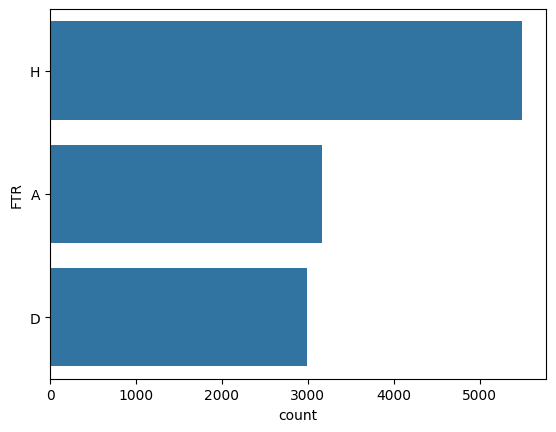

In [40]:
sns.countplot(df["FTR"])

In [41]:
Home_wins=sum(df["FTR"]=="H")
Away_wins=sum(df["FTR"]=="A")
Draws=sum(df["FTR"]=="D")
count=df["FTR"].count()
PercentDrawn = float(Draws/count*100)
PercentWon_Home = float(Home_wins/count*100)
PercentWon_Away = float(Away_wins/count*100)

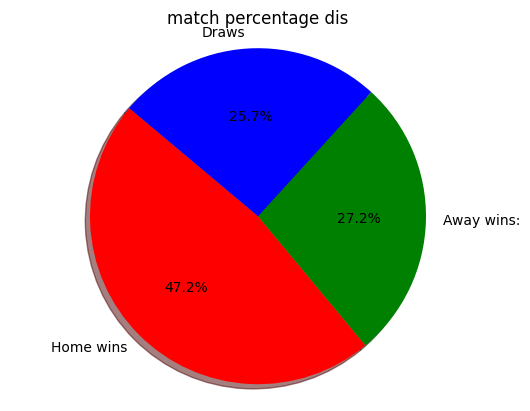

In [42]:
plt.pie([Home_wins,Away_wins,Draws],labels=["Home wins","Away wins:","Draws"], colors=["red","green","blue"],
autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('match percentage dis')
plt.axis('equal')
plt.show()

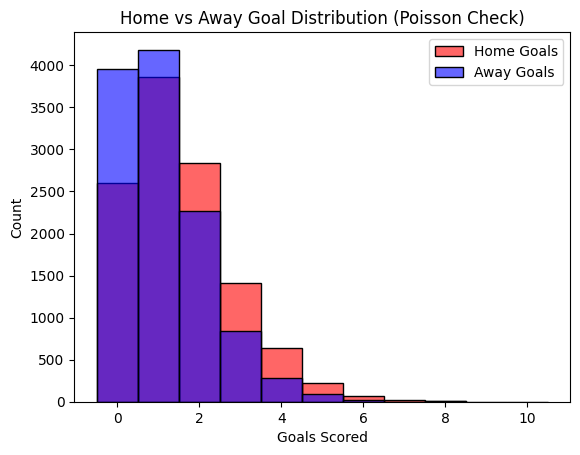

In [43]:
sns.histplot(data=df, x="FTHG", color="red", label="Home Goals", discrete=True, alpha=0.6)
sns.histplot(data=df, x="FTAG", color="blue", label="Away Goals", discrete=True, alpha=0.6)

plt.legend()
plt.title("Home vs Away Goal Distribution (Poisson Check)")
plt.xlabel("Goals Scored")
plt.show()

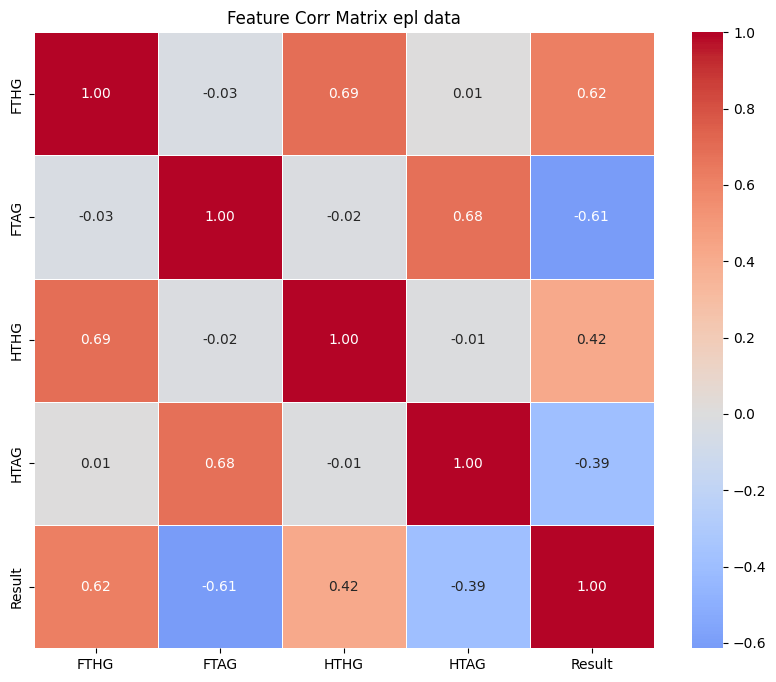

In [44]:
hdf=df.copy()
hdf["Result"]=hdf["FTR"].map({"H":1,"D":0,"A":-1})
ncols=hdf.select_dtypes(include=[np.number])
corr_mtx=ncols.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_mtx,annot=True,fmt=".2f",
           cmap="coolwarm",center=0,linewidths=0.5)
plt.title("Feature Corr Matrix epl data")
plt.show()

In [45]:
df.drop(columns=['Season'], inplace=True, errors='ignore')

In [46]:
df.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR'],
      dtype='object')

In [47]:
# First, check the actual date format in the data
print(df['Date'].head(10))
print(f"Data type: {df['Date'].dtype}")

0    02-09-1995
1    02-09-1995
2    03-09-1995
3    03-09-1995
4    03-09-1995
5    03-09-1995
6    03-09-1995
7    03-09-1995
8    03-09-1995
9    03-09-1995
Name: Date, dtype: object
Data type: object


In [48]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values(by='Date')

In [49]:
df

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
0,1995-09-02,La Coruna,Valencia,3,0,H,2.0,0.0,H
1,1995-09-02,Sp Gijon,Albacete,3,0,H,3.0,0.0,H
2,1995-09-03,Ath Bilbao,Santander,4,0,H,2.0,0.0,H
3,1995-09-03,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D
4,1995-09-03,Celta,Compostela,0,1,A,0.0,0.0,D
...,...,...,...,...,...,...,...,...,...
11661,2025-10-26,Osasuna,Celta,2,3,A,2.0,1.0,H
11662,2025-10-26,Vallecano,Alaves,1,0,H,0.0,0.0,D
11659,2025-10-26,Mallorca,Levante,1,1,D,0.0,1.0,A
11660,2025-10-26,Real Madrid,Barcelona,2,1,H,2.0,1.0,H


In [50]:
home_games =df[['Date', 'HomeTeam', 'FTHG', 'FTAG']].copy()
home_games.columns = ['Date', 'Team', 'GoalsFor', 'GoalsAgainst']

In [51]:
home_games

,Date,Team,GoalsFor,GoalsAgainst
0,1995-09-02,La Coruna,3,0
1,1995-09-02,Sp Gijon,3,0
2,1995-09-03,Ath Bilbao,4,0
3,1995-09-03,Ath Madrid,4,1
4,1995-09-03,Celta,0,1
...,...,...,...,...
11661,2025-10-26,Osasuna,2,3
11662,2025-10-26,Vallecano,1,0
11659,2025-10-26,Mallorca,1,1
11660,2025-10-26,Real Madrid,2,1


In [52]:
away_games =df[['Date', 'AwayTeam', 'FTAG', 'FTHG']].copy()
away_games.columns = ['Date', 'Team', 'GoalsFor', 'GoalsAgainst']


In [53]:
away_games

,Date,Team,GoalsFor,GoalsAgainst
0,1995-09-02,Valencia,0,3
1,1995-09-02,Albacete,0,3
2,1995-09-03,Santander,0,4
3,1995-09-03,Sociedad,1,4
4,1995-09-03,Compostela,1,0
...,...,...,...,...
11661,2025-10-26,Celta,3,2
11662,2025-10-26,Alaves,0,1
11659,2025-10-26,Levante,1,1
11660,2025-10-26,Barcelona,1,2


In [54]:
all_games = pd.concat([home_games, away_games]).sort_values(['Team', 'Date'])

In [55]:
all_games

,Date,Team,GoalsFor,GoalsAgainst
1304,1998-08-29,Alaves,0,0
1323,1998-09-13,Alaves,0,1
1325,1998-09-20,Alaves,1,0
1341,1998-09-27,Alaves,2,1
1345,1998-10-04,Alaves,0,1
...,...,...,...,...
6962,2013-05-05,Zaragoza,3,0
6966,2013-05-10,Zaragoza,0,0
6982,2013-05-19,Zaragoza,1,2
6986,2013-05-26,Zaragoza,0,4


In [56]:
grouped = all_games.groupby('Team')

In [57]:
all_games['Form_GoalsScored'] = grouped['GoalsFor'].transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
all_games['Form_GoalsConceded'] = grouped['GoalsAgainst'].transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())

In [58]:
df = pd.merge(df, all_games[['Date', 'Team', 'Form_GoalsScored', 'Form_GoalsConceded']],
                 left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
df.rename(columns={'Form_GoalsScored': 'Home_GoalsScored_Last5', 
                      'Form_GoalsConceded': 'Home_GoalsConceded_Last5'}, inplace=True)
df.drop(columns=['Team'], inplace=True)


In [59]:
df = pd.merge(df, all_games[['Date', 'Team', 'Form_GoalsScored', 'Form_GoalsConceded']],
                 left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
df.rename(columns={'Form_GoalsScored': 'Away_GoalsScored_Last5', 
                      'Form_GoalsConceded': 'Away_GoalsConceded_Last5'}, inplace=True)
df.drop(columns=['Date', 'Team'], inplace=True)

In [60]:
all_games

,Date,Team,GoalsFor,GoalsAgainst,Form_GoalsScored,Form_GoalsConceded
1304,1998-08-29,Alaves,0,0,NaN,NaN
1323,1998-09-13,Alaves,0,1,0.000000,0.000000
1325,1998-09-20,Alaves,1,0,0.000000,0.500000
1341,1998-09-27,Alaves,2,1,0.333333,0.333333
1345,1998-10-04,Alaves,0,1,0.750000,0.500000
...,...,...,...,...,...,...
6962,2013-05-05,Zaragoza,3,0,1.400000,2.200000
6966,2013-05-10,Zaragoza,0,0,1.800000,2.000000
6982,2013-05-19,Zaragoza,1,2,1.400000,1.400000
6986,2013-05-26,Zaragoza,0,4,1.600000,1.200000


In [61]:
all_games.isna().sum()

Date                   0
Team                   0
GoalsFor               0
GoalsAgainst           0
Form_GoalsScored      48
Form_GoalsConceded    48
dtype: int64

In [62]:
# Option 1: Fill NaN with 0 (assume no form history = average 0 goals)
all_games['Form_GoalsScored'].fillna(0, inplace=True)
all_games['Form_GoalsConceded'].fillna(0, inplace=True)

# Option 2: Fill with the overall mean
all_games['Form_GoalsScored'].fillna(all_games['Form_GoalsScored'].mean(), inplace=True)
all_games['Form_GoalsConceded'].fillna(all_games['Form_GoalsConceded'].mean(), inplace=True)

# Option 3: Forward fill (use the next available value)
all_games['Form_GoalsScored'].fillna(method='bfill', inplace=True)

/tmp/ipykernel_28911/3336663247.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_games['Form_GoalsScored'].fillna(0, inplace=True)
/tmp/ipykernel_28911/3336663247.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [63]:
all_games.isna().sum()

Date                  0
Team                  0
GoalsFor              0
GoalsAgainst          0
Form_GoalsScored      0
Form_GoalsConceded    0
dtype: int64

In [64]:
df

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Home_GoalsScored_Last5,Home_GoalsConceded_Last5,Away_GoalsScored_Last5,Away_GoalsConceded_Last5
0,La Coruna,Valencia,3,0,H,2.0,0.0,H,NaN,NaN,NaN,NaN
1,Sp Gijon,Albacete,3,0,H,3.0,0.0,H,NaN,NaN,NaN,NaN
2,Ath Bilbao,Santander,4,0,H,2.0,0.0,H,NaN,NaN,NaN,NaN
3,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D,NaN,NaN,NaN,NaN
4,Celta,Compostela,0,1,A,0.0,0.0,D,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
11657,Osasuna,Celta,2,3,A,2.0,1.0,H,0.8,1.4,1.0,1.2
11658,Vallecano,Alaves,1,0,H,0.0,0.0,D,1.4,1.0,1.0,1.0
11659,Mallorca,Levante,1,1,D,0.0,1.0,A,1.2,1.0,1.6,1.6
11660,Real Madrid,Barcelona,2,1,H,2.0,1.0,H,2.4,1.4,2.2,1.4


In [65]:
df.isna().sum()

HomeTeam                     0
AwayTeam                     0
FTHG                         0
FTAG                         0
FTR                          0
HTHG                         0
HTAG                         0
HTR                          0
Home_GoalsScored_Last5      24
Home_GoalsConceded_Last5    24
Away_GoalsScored_Last5      24
Away_GoalsConceded_Last5    24
dtype: int64

In [66]:
df

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Home_GoalsScored_Last5,Home_GoalsConceded_Last5,Away_GoalsScored_Last5,Away_GoalsConceded_Last5
0,La Coruna,Valencia,3,0,H,2.0,0.0,H,NaN,NaN,NaN,NaN
1,Sp Gijon,Albacete,3,0,H,3.0,0.0,H,NaN,NaN,NaN,NaN
2,Ath Bilbao,Santander,4,0,H,2.0,0.0,H,NaN,NaN,NaN,NaN
3,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D,NaN,NaN,NaN,NaN
4,Celta,Compostela,0,1,A,0.0,0.0,D,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
11657,Osasuna,Celta,2,3,A,2.0,1.0,H,0.8,1.4,1.0,1.2
11658,Vallecano,Alaves,1,0,H,0.0,0.0,D,1.4,1.0,1.0,1.0
11659,Mallorca,Levante,1,1,D,0.0,1.0,A,1.2,1.0,1.6,1.6
11660,Real Madrid,Barcelona,2,1,H,2.0,1.0,H,2.4,1.4,2.2,1.4


In [68]:
df.dropna(inplace=True)

In [69]:
df.to_csv("LaLiga_df.csv")